a) Fine-tune a pretrained model using the DeepDRiD dataset. (5 points)  
1. Download the DeepDRiD dataset from the provided link along with the template code which
would provide you with an explanation on diabetic retinopathy and the dataset itself. All the
images for training, validation, and evaluation are 512 by 512 in size.
2. Fine-tune an ImageNet pretrained model (e.g., ResNet18, ResNet34, VGG, EfficientNet,
DenseNet) on the DeepDRiD dataset. Evaluate and test it on the validation and test sets. Your
goal here is to reach the highest Cohen Kappa score you can get.
3. Play around different image augmentation techniques and check whether it boosts your
evaluation metrics or decreases them.
4. Save the fine-tuned model.

# Import Libraries

In [ ]:
import os
import sys
import copy
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from torchvision import models, transforms
from PIL import Image
from sklearn.metrics import cohen_kappa_score, precision_score, recall_score, accuracy_score
from torch.utils.data import Dataset
from tqdm import tqdm

In [ ]:
# Set seeds for Python's `random`
random.seed(42)

# Set seeds for NumPy
np.random.seed(42)

# Set seeds for PyTorch (if PyHRPN is dependent on PyTorch)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

In [ ]:


class RetinopathyDataset(Dataset):
    def __init__(self, ann_file, image_dir, transform=None, mode='single', test=False):
        self.ann_file = ann_file
        self.image_dir = image_dir
        self.transform = transform

        self.test = test
        self.mode = mode

        if self.mode == 'single':
            self.data = self.load_data()
        else:
            self.data = self.load_dual_data()

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        if self.mode == 'single':
            return self.get_item(index)
        else:
            return self.get_item_dual(index)

    # 1. single image
    def load_data(self):
        df = pd.read_csv(self.ann_file)

        data = []
        for _, row in df.iterrows():
            file_info = dict()
            file_info['img_path'] = os.path.join(self.image_dir, row['img_path'])
            if not self.test:
                file_info['dr_level'] = int(row['patient_DR_Level'])
            data.append(file_info)
        return data

    def get_item(self, index):
        data = self.data[index]
        img = Image.open(data['img_path']).convert('RGB')
        if self.transform:
            img = self.transform(img)

        if not self.test:
            label = torch.tensor(data['dr_level'], dtype=torch.int64)
            return img, label
        else:
            return img

    # 2. dual image
    def load_dual_data(self):
        df = pd.read_csv(self.ann_file)

        df['prefix'] = df['image_id'].str.split('_').str[0]  # The patient id of each image
        df['suffix'] = df['image_id'].str.split('_').str[1].str[0]  # The left or right eye
        grouped = df.groupby(['prefix', 'suffix'])

        data = []
        for (prefix, suffix), group in grouped:
            file_info = dict()
            file_info['img_path1'] = os.path.join(self.image_dir, group.iloc[0]['img_path'])
            file_info['img_path2'] = os.path.join(self.image_dir, group.iloc[1]['img_path'])
            if not self.test:
                file_info['dr_level'] = int(group.iloc[0]['patient_DR_Level'])
            data.append(file_info)
        return data

    def get_item_dual(self, index):
        data = self.data[index]
        img1 = Image.open(data['img_path1']).convert('RGB')
        img2 = Image.open(data['img_path2']).convert('RGB')

        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)

        if not self.test:
            label = torch.tensor(data['dr_level'], dtype=torch.int64)
            return [img1, img2], label
        else:
            return [img1, img2]



def train_model(model, train_loader, val_loader, device, criterion, optimizer, lr_scheduler, num_epochs=25,
                checkpoint_path='model.pth'):
    best_model = model.state_dict()
    best_epoch = None
    best_val_kappa = -1.0  # Initialize the best kappa score

    # Initialize metrics
    training_loss = []
    validation_loss = []
    training_accuracy = []
    validation_accuracy = []
    train_kappa = []
    val_kappa_list = []

    for epoch in range(1, num_epochs + 1):
        print(f'\nEpoch {epoch}/{num_epochs}')
        running_loss = []
        all_preds = []
        all_labels = []

        model.train()

        with tqdm(total=len(train_loader), desc=f'Training', unit=' batch', file=sys.stdout) as pbar:
            for images, labels in train_loader:
                if not isinstance(images, list):
                    images = images.to(device)  # single image case
                else:
                    images = [x.to(device) for x in images]  # dual images case

                labels = labels.to(device)

                optimizer.zero_grad()

                outputs = model(images)
                loss = criterion(outputs, labels.long())

                loss.backward()
                optimizer.step()

                preds = torch.argmax(outputs, 1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

                running_loss.append(loss.item())

                pbar.set_postfix({'lr': f'{optimizer.param_groups[0]["lr"]:.1e}', 'Loss': f'{loss.item():.4f}'})
                pbar.update(1)

        lr_scheduler.step()

        epoch_loss = sum(running_loss) / len(running_loss)

        train_metrics = compute_metrics(all_preds, all_labels, per_class=True)
        kappa, accuracy, precision, recall = train_metrics[:4]

        print(f'[Train] Kappa: {kappa:.4f} Accuracy: {accuracy:.4f} '
              f'Precision: {precision:.4f} Recall: {recall:.4f} Loss: {epoch_loss:.4f}')

        if len(train_metrics) > 4:
            precision_per_class, recall_per_class = train_metrics[4:]
            for i, (precision, recall) in enumerate(zip(precision_per_class, recall_per_class)):
                print(f'[Train] Class {i}: Precision: {precision:.4f}, Recall: {recall:.4f}')

        # Evaluation on the validation set at the end of each epoch
        val_metrics, val_loss= evaluate_model(criterion, model, val_loader, device)
        val_kappa, val_accuracy, val_precision, val_recall = val_metrics[:4]
        print(f'[Val] Kappa: {val_kappa:.4f} Accuracy: {val_accuracy:.4f} '
              f'Precision: {val_precision:.4f} Recall: {val_recall:.4f}')

        if val_kappa > best_val_kappa:
            best_val_kappa = val_kappa
            best_epoch = epoch
            best_model = model.state_dict()
            torch.save(best_model, checkpoint_path)

        training_loss.append(epoch_loss)
        validation_loss.append(val_loss)
        training_accuracy.append(accuracy)
        validation_accuracy.append(val_accuracy)
        train_kappa.append(kappa)
        val_kappa_list.append(val_kappa)

    print(f'[Val] Best kappa: {best_val_kappa:.4f}, Epoch {best_epoch}')

    return model, training_loss, validation_loss, training_accuracy, validation_accuracy, train_kappa, val_kappa_list


def evaluate_model(criterion, model, test_loader, device, test_only=False, prediction_path='./test_predictions.csv'):
    model.eval()

    all_preds = []
    all_labels = []
    all_image_ids = []

    with tqdm(total=len(test_loader), desc=f'Evaluating', unit=' batch', file=sys.stdout) as pbar:
        for i, data in enumerate(test_loader):

            if test_only:
                images = data
            else:
                images, labels = data

            if not isinstance(images, list):
                images = images.to(device)  # single image case
            else:
                images = [x.to(device) for x in images]  # dual images case

            with torch.no_grad():
                outputs = model(images)
                preds = torch.argmax(outputs, 1)
            if not test_only:
                val_loss = criterion(outputs, labels.to(device).long())
                val_loss = val_loss.cpu().numpy()

            if not isinstance(images, list):
                # single image case
                all_preds.extend(preds.cpu().numpy())
                image_ids = [
                    os.path.basename(test_loader.dataset.data[idx]['img_path']) for idx in
                    range(i * test_loader.batch_size, i * test_loader.batch_size + len(images))
                ]
                all_image_ids.extend(image_ids)
                if not test_only:
                    all_labels.extend(labels.numpy())
            else:
                # dual images case
                for k in range(2):
                    all_preds.extend(preds.cpu().numpy())
                    image_ids = [
                        os.path.basename(test_loader.dataset.data[idx][f'img_path{k + 1}']) for idx in
                        range(i * test_loader.batch_size, i * test_loader.batch_size + len(images[k]))
                    ]
                    all_image_ids.extend(image_ids)
                    if not test_only:
                        all_labels.extend(labels.numpy())

            pbar.update(1)

    # Save predictions to csv file for Kaggle online evaluation
    if test_only:
        df = pd.DataFrame({
            'ID': all_image_ids,
            'TARGET': all_preds
        })
        df.to_csv(prediction_path, index=False)
        print(f'[Test] Save predictions to {os.path.abspath(prediction_path)}')
    else:
        metrics = compute_metrics(all_preds, all_labels)
        return metrics, val_loss

def compute_metrics(preds, labels, per_class=False):
    kappa = cohen_kappa_score(labels, preds, weights='quadratic')
    accuracy = accuracy_score(labels, preds)
    precision = precision_score(labels, preds, average='weighted', zero_division=0)
    recall = recall_score(labels, preds, average='weighted', zero_division=0)

    # Calculate and print precision and recall for each class
    if per_class:
        precision_per_class = precision_score(labels, preds, average=None, zero_division=0)
        recall_per_class = recall_score(labels, preds, average=None, zero_division=0)
        return kappa, accuracy, precision, recall, precision_per_class, recall_per_class

    return kappa, accuracy, precision, recall

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Augmentation Functions

In [ ]:
class SLORandomPad:
    def __init__(self, size):
        self.size = size

    def __call__(self, img):
        pad_width = max(0, self.size[0] - img.width)
        pad_height = max(0, self.size[1] - img.height)
        pad_left = random.randint(0, pad_width)
        pad_top = random.randint(0, pad_height)
        pad_right = pad_width - pad_left
        pad_bottom = pad_height - pad_top
        return transforms.functional.pad(img, (pad_left, pad_top, pad_right, pad_bottom))


class FundRandomRotate:
    def __init__(self, prob, degree):
        self.prob = prob
        self.degree = degree

    def __call__(self, img):
        if random.random() < self.prob:
            angle = random.uniform(-self.degree, self.degree)
            return transforms.functional.rotate(img, angle)
        return img

In [ ]:
class SingleModels(nn.Module):
    def __init__(self, model_name, num_classes=5):
        super().__init__()
        self.model_name = model_name
        if self.model_name == 'resnet18':
            self.backbone = models.resnet18(pretrained=True)
            num_ftrs = self.backbone.fc.in_features
            self.backbone.fc = nn.Identity()
            self.fc = nn.Linear(num_ftrs, num_classes)
        elif self.model_name == 'resnet34':
            self.backbone = models.resnet34(pretrained=True)
            num_ftrs = self.backbone.fc.in_features
            self.backbone.fc = nn.Identity()
            self.fc = nn.Linear(num_ftrs, num_classes)
        elif self.model_name == 'vgg16':
            self.backbone = models.vgg16(pretrained=True)
            num_ftrs = self.backbone.classifier[6].in_features
            self.backbone.classifier[6] = nn.Linear(num_ftrs, num_classes)
        elif self.model_name == 'efficientnet_b0':
            self.backbone = models.efficientnet_b0(pretrained=True)
            num_ftrs = self.backbone.classifier[1].in_features
            self.backbone.classifier[1] = nn.Linear(num_ftrs, num_classes)
        elif self.model_name == 'densenet121':
            self.backbone = models.densenet121(pretrained=True)
            num_ftrs = self.backbone.classifier.in_features
            self.backbone.classifier = nn.Linear(num_ftrs, num_classes)

    def forward(self, x):
        x = self.backbone(x)
        if self.model_name in ['resnet18', 'resnet34']:
            x = self.fc(x)
        return x


# Hyper Parameters

In [ ]:
# Hyper Parameters
batch_size = 48
num_classes = 5  # 5 DR levels
learning_rate = 0.0001
num_epochs = 20

# Transformers

In [ ]:
transform_train = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop((210, 210)),
    SLORandomPad((224, 224)),
    FundRandomRotate(prob=0.5, degree=30),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ColorJitter(brightness=(0.1, 0.9)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Main Loop

In [ ]:
# Define the weighted CrossEntropyLoss
criterion = nn.CrossEntropyLoss()

# Use GPU device is possible
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


# Single Models

In [ ]:
# Choose between 'single image' and 'dual images' pipeline
# This will affect the model definition, dataset pipeline, training and evaluation

mode = 'single'  # forward single image to the model each time

In [ ]:
# Create datasets
train_dataset = RetinopathyDataset('/content/drive/MyDrive/DL_Project/DeepDRiD/train.csv', '/content/drive/MyDrive/DL_Project/DeepDRiD/train/', transform_train, mode)
val_dataset = RetinopathyDataset('/content/drive/MyDrive/DL_Project/DeepDRiD/val.csv', '/content/drive/MyDrive/DL_Project/DeepDRiD/val/', transform_test, mode)
test_dataset = RetinopathyDataset('/content/drive/MyDrive/DL_Project/DeepDRiD/test.csv', '/content/drive/MyDrive/DL_Project/DeepDRiD//test/', transform_test, mode, test=True)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

ResNet18

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


SingleModels(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, tra

<ipython-input-12-df4312fd8dab>:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load('/content/drive/MyDrive/DL_Project/part_a/aug_resnet18.pth', map_lo

Evaluating: 100%|██████████| 9/9 [02:15<00:00, 15.08s/ batch]
[Test] Save predictions to /content/drive/MyDrive/DL_Project/part_a/aug_test_predictions_resnet18.csv


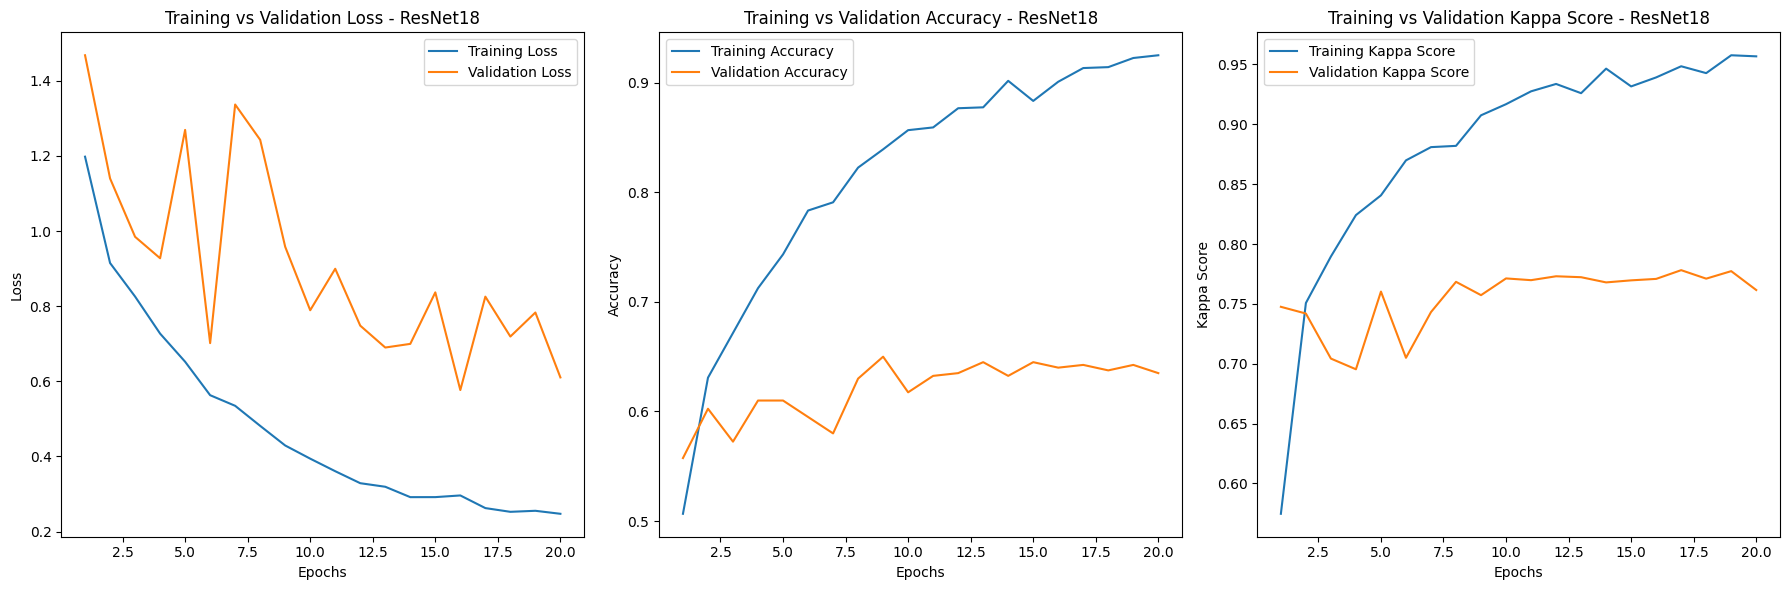

In [ ]:
model_name = 'resnet18'
# Define the model
model = SingleModels(model_name)

print(model, '\n')
print('Pipeline Mode:', mode)

# Move class weights to the device
model = model.to(device)

# Optimizer and Learning rate scheduler
optimizer = torch.optim.Adam(params=model.parameters(), lr=learning_rate)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

# Train and evaluate the model with the training and validation set
model, training_loss, validation_loss, training_accuracy, validation_accuracy, train_kappa, val_kappa_list = train_model(
    model, train_loader, val_loader, device, criterion, optimizer,
    lr_scheduler=lr_scheduler, num_epochs=num_epochs,
    checkpoint_path='/content/drive/MyDrive/DL_Project/part_a/aug_resnet18.pth'
)

# Load the pretrained checkpoint
state_dict = torch.load('/content/drive/MyDrive/DL_Project/part_a/aug_resnet18.pth', map_location='cpu')
model.load_state_dict(state_dict, strict=True)

# Make predictions on testing set and save the prediction results
evaluate_model(criterion, model, test_loader, device, test_only=True, prediction_path='/content/drive/MyDrive/DL_Project/part_a/aug_test_predictions_resnet18.csv')

epochs_range = range(1, num_epochs + 1)

# Plot Loss
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
plt.plot(epochs_range, training_loss, label="Training Loss")
plt.plot(epochs_range, validation_loss, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss - ResNet18")
plt.legend()

# Plot Accuracy
plt.subplot(1, 3, 2)
plt.plot(epochs_range, training_accuracy, label="Training Accuracy")
plt.plot(epochs_range, validation_accuracy, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy - ResNet18")
plt.legend()

# Plot Kappa Score
plt.subplot(1, 3, 3)
plt.plot(epochs_range, train_kappa, label="Training Kappa Score")
plt.plot(epochs_range, val_kappa_list, label="Validation Kappa Score")
plt.xlabel("Epochs")
plt.ylabel("Kappa Score")
plt.title("Training vs Validation Kappa Score - ResNet18")
plt.legend()
plt.tight_layout()
plt.show()

ResNet34

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth
100%|██████████| 83.3M/83.3M [00:00<00:00, 173MB/s]


SingleModels(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, tra

<ipython-input-13-b253d0c22d06>:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load('/content/drive/MyDrive/DL_Project/part_a/aug_resnet34.pth', map_lo

Evaluating: 100%|██████████| 9/9 [00:04<00:00,  2.02 batch/s]
[Test] Save predictions to /content/drive/MyDrive/DL_Project/part_a/aug_test_predictions_resnet34.csv


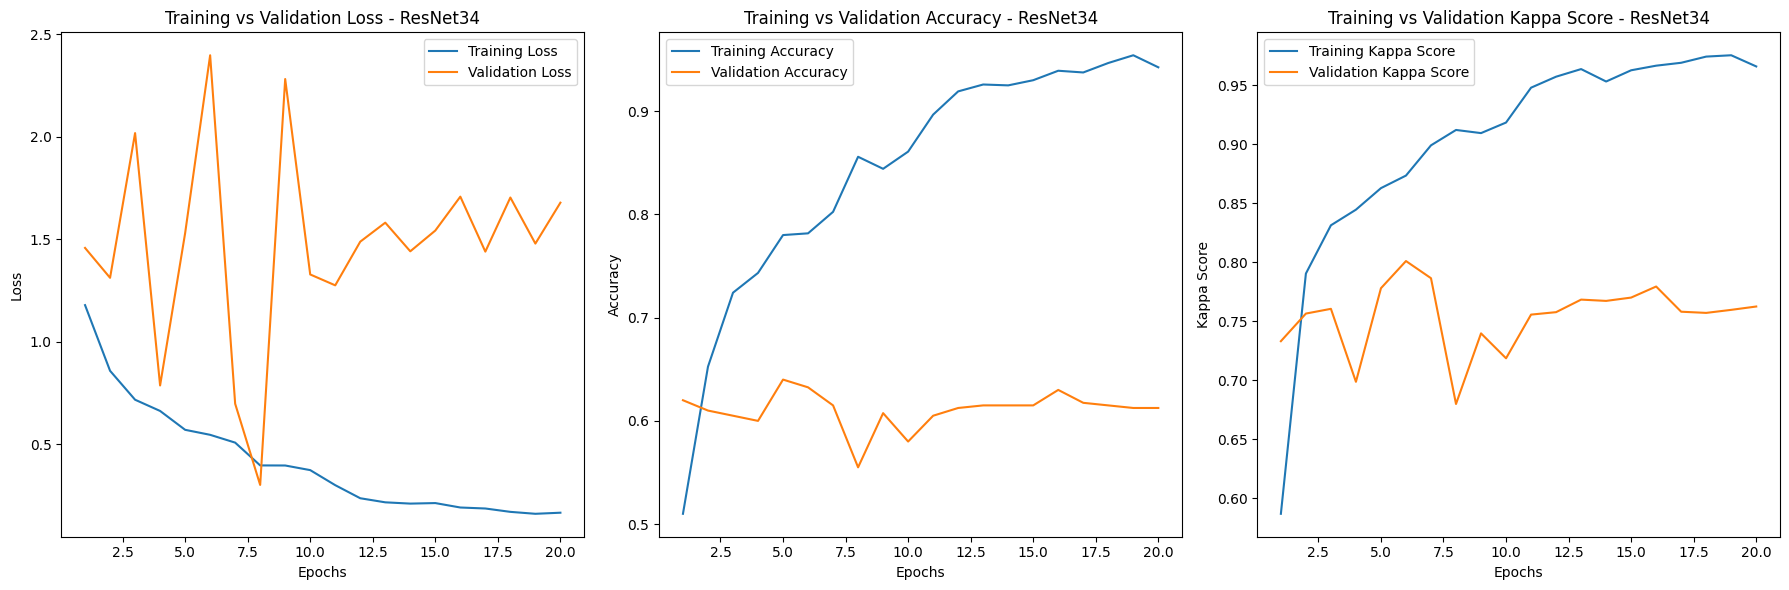

In [ ]:
model_name = 'resnet34'
# Define the model
model = SingleModels(model_name)

print(model, '\n')
print('Pipeline Mode:', mode)

# Move class weights to the device
model = model.to(device)

# Optimizer and Learning rate scheduler
optimizer = torch.optim.Adam(params=model.parameters(), lr=learning_rate)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

# Train and evaluate the model with the training and validation set
model, training_loss, validation_loss, training_accuracy, validation_accuracy, train_kappa, val_kappa_list = train_model(
    model, train_loader, val_loader, device, criterion, optimizer,
    lr_scheduler=lr_scheduler, num_epochs=num_epochs,
    checkpoint_path='/content/drive/MyDrive/DL_Project/part_a/aug_resnet34.pth'
)

# Load the pretrained checkpoint
state_dict = torch.load('/content/drive/MyDrive/DL_Project/part_a/aug_resnet34.pth', map_location='cpu')
model.load_state_dict(state_dict, strict=True)

# Make predictions on testing set and save the prediction results
evaluate_model(criterion, model, test_loader, device, test_only=True, prediction_path='/content/drive/MyDrive/DL_Project/part_a/aug_test_predictions_resnet34.csv')

epochs_range = range(1, num_epochs + 1)

# Plot Loss
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
plt.plot(epochs_range, training_loss, label="Training Loss")
plt.plot(epochs_range, validation_loss, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss - ResNet34")
plt.legend()

# Plot Accuracy
plt.subplot(1, 3, 2)
plt.plot(epochs_range, training_accuracy, label="Training Accuracy")
plt.plot(epochs_range, validation_accuracy, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy - ResNet34")
plt.legend()

# Plot Kappa Score
plt.subplot(1, 3, 3)
plt.plot(epochs_range, train_kappa, label="Training Kappa Score")
plt.plot(epochs_range, val_kappa_list, label="Validation Kappa Score")
plt.xlabel("Epochs")
plt.ylabel("Kappa Score")
plt.title("Training vs Validation Kappa Score - ResNet34")
plt.legend()
plt.tight_layout()
plt.show()

VGG

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:03<00:00, 173MB/s]


SingleModels(
  (backbone): VGG(
    (features): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (6): ReLU(inplace=True)
      (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (8): ReLU(inplace=True)
      (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (11): ReLU(inplace=True)
      (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (13): ReLU(inplace=True)
      (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (15): ReLU(inplace=True)
    

<ipython-input-14-948a54c731d2>:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load('/content/drive/MyDrive/DL_Project/part_a/aug_vgg16.pth', map_locat

Evaluating: 100%|██████████| 9/9 [00:05<00:00,  1.75 batch/s]
[Test] Save predictions to /content/drive/MyDrive/DL_Project/part_a/aug_test_predictions_vgg16.csv


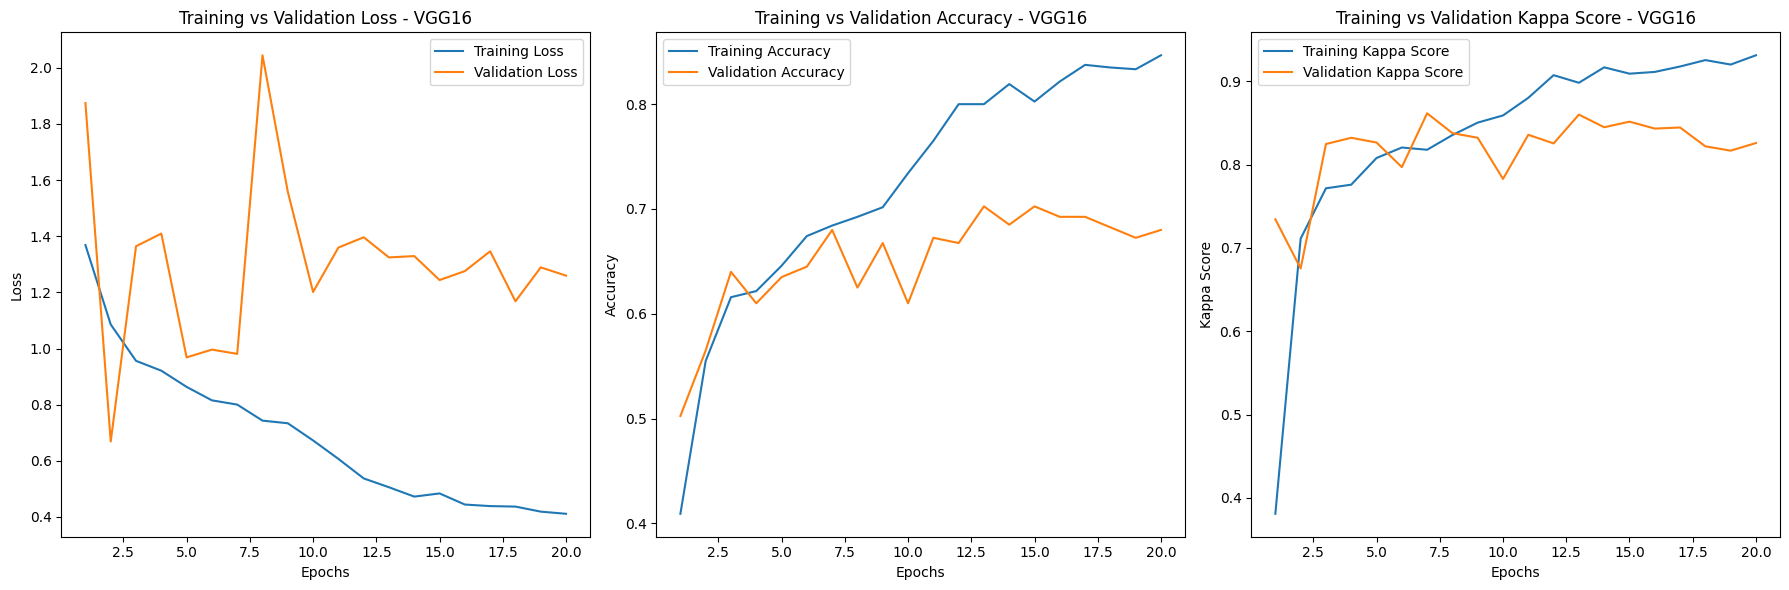

In [ ]:
model_name = 'vgg16'
# Define the model
model = SingleModels(model_name)

print(model, '\n')
print('Pipeline Mode:', mode)

# Move class weights to the device
model = model.to(device)

# Optimizer and Learning rate scheduler
optimizer = torch.optim.Adam(params=model.parameters(), lr=learning_rate)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

# Train and evaluate the model with the training and validation set
model, training_loss, validation_loss, training_accuracy, validation_accuracy, train_kappa, val_kappa_list = train_model(
    model, train_loader, val_loader, device, criterion, optimizer,
    lr_scheduler=lr_scheduler, num_epochs=num_epochs,
    checkpoint_path='/content/drive/MyDrive/DL_Project/part_a/aug_vgg16.pth'
)

# Load the pretrained checkpoint
state_dict = torch.load('/content/drive/MyDrive/DL_Project/part_a/aug_vgg16.pth', map_location='cpu')
model.load_state_dict(state_dict, strict=True)

# Make predictions on testing set and save the prediction results
evaluate_model(criterion, model, test_loader, device, test_only=True, prediction_path='/content/drive/MyDrive/DL_Project/part_a/aug_test_predictions_vgg16.csv')

epochs_range = range(1, num_epochs + 1)

# Plot Loss
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
plt.plot(epochs_range, training_loss, label="Training Loss")
plt.plot(epochs_range, validation_loss, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss - VGG16")
plt.legend()

# Plot Accuracy
plt.subplot(1, 3, 2)
plt.plot(epochs_range, training_accuracy, label="Training Accuracy")
plt.plot(epochs_range, validation_accuracy, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy - VGG16")
plt.legend()

# Plot Kappa Score
plt.subplot(1, 3, 3)
plt.plot(epochs_range, train_kappa, label="Training Kappa Score")
plt.plot(epochs_range, val_kappa_list, label="Validation Kappa Score")
plt.xlabel("Epochs")
plt.ylabel("Kappa Score")
plt.title("Training vs Validation Kappa Score - VGG16")
plt.legend()
plt.tight_layout()
plt.show()

EfficientNet

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 110MB/s] 


SingleModels(
  (backbone): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
              (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
              (activation): SiLU(inplace=True)
              (scale

<ipython-input-15-02990fdafcd3>:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load('/content/drive/MyDrive/DL_Project/part_a/aug_efficientnet_b0.pth',


[Val] Kappa: 0.7432 Accuracy: 0.6425 Precision: 0.6421 Recall: 0.6425
[Val] Best kappa: 0.7623, Epoch 10
Evaluating: 100%|██████████| 9/9 [00:04<00:00,  2.16 batch/s]
[Test] Save predictions to /content/drive/MyDrive/DL_Project/part_a/aug_test_predictions_efficientnet_b0.csv


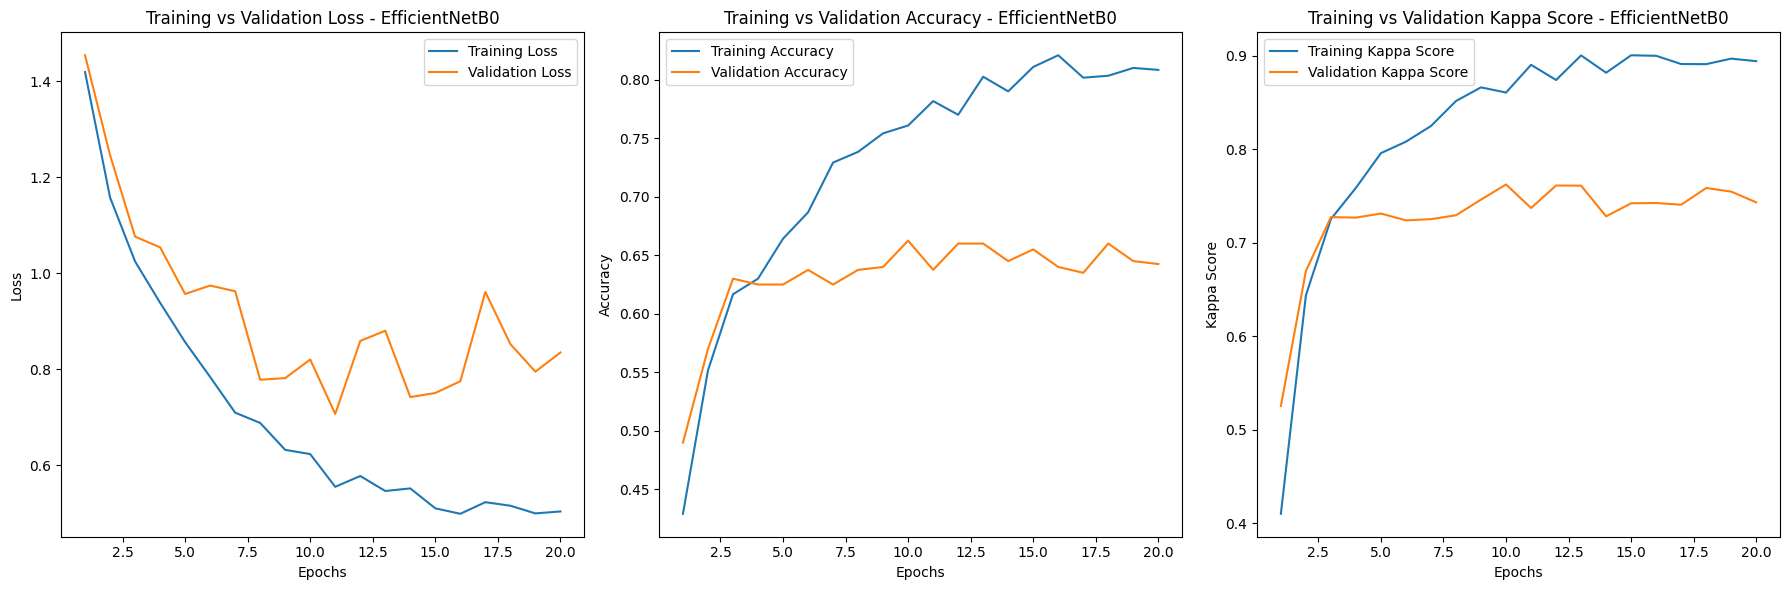

In [ ]:
model_name = 'efficientnet_b0'
# Define the model
model = SingleModels(model_name)

print(model, '\n')
print('Pipeline Mode:', mode)

# Move class weights to the device
model = model.to(device)

# Optimizer and Learning rate scheduler
optimizer = torch.optim.Adam(params=model.parameters(), lr=learning_rate)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

# Train and evaluate the model with the training and validation set
model, training_loss, validation_loss, training_accuracy, validation_accuracy, train_kappa, val_kappa_list = train_model(
    model, train_loader, val_loader, device, criterion, optimizer,
    lr_scheduler=lr_scheduler, num_epochs=num_epochs,
    checkpoint_path='/content/drive/MyDrive/DL_Project/part_a/aug_efficientnet_b0.pth'
)

# Load the pretrained checkpoint
state_dict = torch.load('/content/drive/MyDrive/DL_Project/part_a/aug_efficientnet_b0.pth', map_location='cpu')
model.load_state_dict(state_dict, strict=True)

# Make predictions on testing set and save the prediction results
evaluate_model(criterion, model, test_loader, device, test_only=True, prediction_path='/content/drive/MyDrive/DL_Project/part_a/aug_test_predictions_efficientnet_b0.csv')

epochs_range = range(1, num_epochs + 1)

# Plot Loss
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
plt.plot(epochs_range, training_loss, label="Training Loss")
plt.plot(epochs_range, validation_loss, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss - EfficientNetB0")
plt.legend()

# Plot Accuracy
plt.subplot(1, 3, 2)
plt.plot(epochs_range, training_accuracy, label="Training Accuracy")
plt.plot(epochs_range, validation_accuracy, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy - EfficientNetB0")
plt.legend()

# Plot Kappa Score
plt.subplot(1, 3, 3)
plt.plot(epochs_range, train_kappa, label="Training Kappa Score")
plt.plot(epochs_range, val_kappa_list, label="Validation Kappa Score")
plt.xlabel("Epochs")
plt.ylabel("Kappa Score")
plt.title("Training vs Validation Kappa Score - EfficientNetB0")
plt.legend()
plt.tight_layout()
plt.show()

DenseNet

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth
100%|██████████| 30.8M/30.8M [00:00<00:00, 151MB/s]


SingleModels(
  (backbone): DenseNet(
    (features): Sequential(
      (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu0): ReLU(inplace=True)
      (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (denseblock1): _DenseBlock(
        (denselayer1): _DenseLayer(
          (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu1): ReLU(inplace=True)
          (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu2): ReLU(inplace=True)
          (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        )
        (denselayer2): _DenseLayer(
          (norm1): BatchNorm2d(96, eps=1e-05, moment

<ipython-input-16-90d4f6debf72>:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load('/content/drive/MyDrive/DL_Project/part_a/aug_densenet121.pth', map

Evaluating: 100%|██████████| 9/9 [00:04<00:00,  1.80 batch/s]
[Test] Save predictions to /content/drive/MyDrive/DL_Project/part_a/aug_test_predictions_densenet121.csv


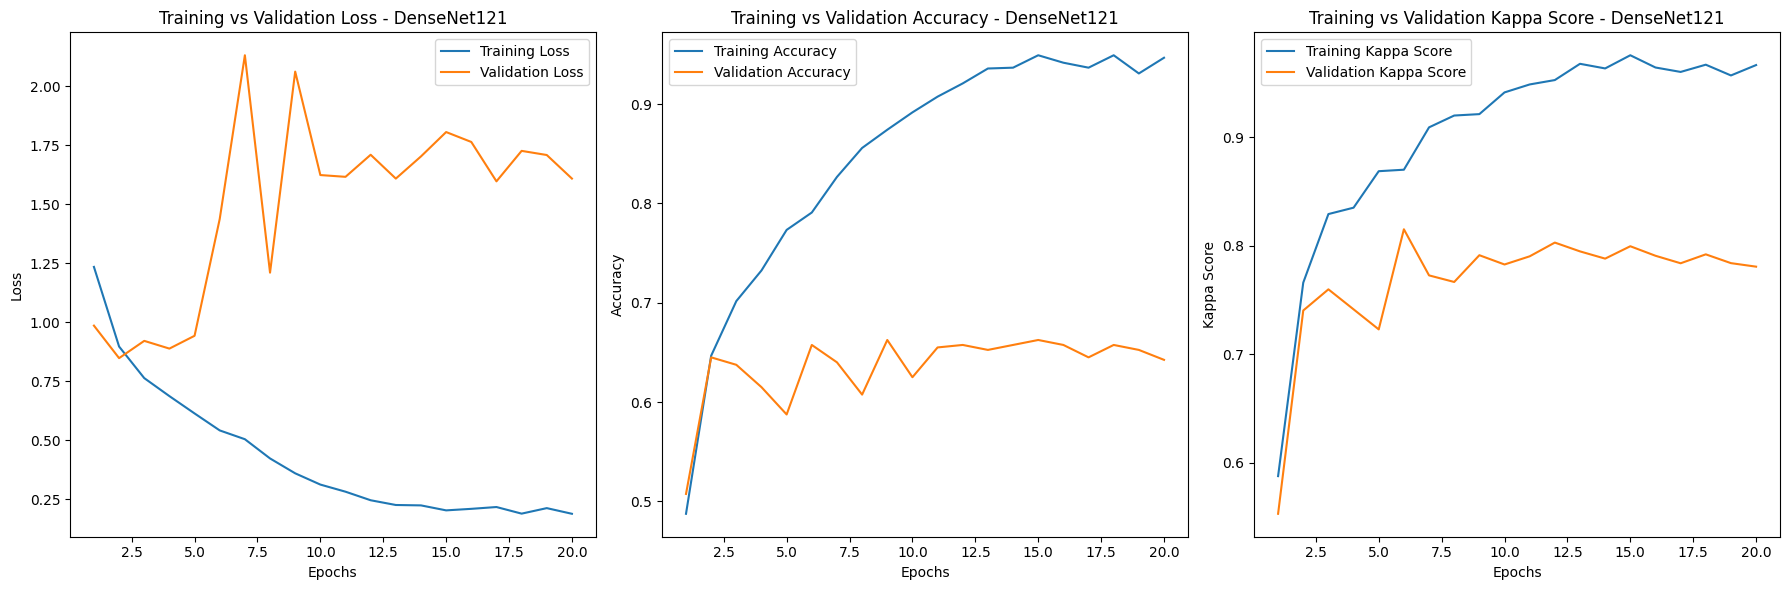

In [ ]:
model_name = 'densenet121'
# Define the model
model = SingleModels(model_name)

print(model, '\n')
print('Pipeline Mode:', mode)

# Move class weights to the device
model = model.to(device)

# Optimizer and Learning rate scheduler
optimizer = torch.optim.Adam(params=model.parameters(), lr=learning_rate)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

# Train and evaluate the model with the training and validation set
model, training_loss, validation_loss, training_accuracy, validation_accuracy, train_kappa, val_kappa_list = train_model(
    model, train_loader, val_loader, device, criterion, optimizer,
    lr_scheduler=lr_scheduler, num_epochs=num_epochs,
    checkpoint_path='/content/drive/MyDrive/DL_Project/part_a/aug_densenet121.pth'
)

# Load the pretrained checkpoint
state_dict = torch.load('/content/drive/MyDrive/DL_Project/part_a/aug_densenet121.pth', map_location='cpu')
model.load_state_dict(state_dict, strict=True)

# Make predictions on testing set and save the prediction results
evaluate_model(criterion, model, test_loader, device, test_only=True, prediction_path='/content/drive/MyDrive/DL_Project/part_a/aug_test_predictions_densenet121.csv')

epochs_range = range(1, num_epochs + 1)

# Plot Loss
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
plt.plot(epochs_range, training_loss, label="Training Loss")
plt.plot(epochs_range, validation_loss, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss - DenseNet121")
plt.legend()

# Plot Accuracy
plt.subplot(1, 3, 2)
plt.plot(epochs_range, training_accuracy, label="Training Accuracy")
plt.plot(epochs_range, validation_accuracy, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy - DenseNet121")
plt.legend()

# Plot Kappa Score
plt.subplot(1, 3, 3)
plt.plot(epochs_range, train_kappa, label="Training Kappa Score")
plt.plot(epochs_range, val_kappa_list, label="Validation Kappa Score")
plt.xlabel("Epochs")
plt.ylabel("Kappa Score")
plt.title("Training vs Validation Kappa Score - DenseNet121")
plt.legend()
plt.tight_layout()
plt.show()